# Comparing the genes and transcripts per cell for the following segmentation methods: Xenium, Proseg, Cellpose

In [1]:
import scanpy as sc 
import anndata as ad 

In [46]:
#read in individual raw experiments

xen_datas = [sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__ctrl__20260211__140710\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__D3IMQ__20260211__140710\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__D7IMQ__20260211__140710\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__D10imq__20260211__140710\cell_feature_matrix.h5"),
]

proseg_datas = [sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Outputs from Julia\outs psoriasis ctrl\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Outputs from Julia\outs d3 psoriasis\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Outputs from Julia\outs d7 psoriasis\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Outputs from Julia\outs d10 psoriasis\cell_feature_matrix.h5"),
]

cellpose_datas = [sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\Ctrl_reseg\outs\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\D3IMQ_reseg\outs\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\D7IMQ_reseg\outs\cell_feature_matrix.h5"),
            sc.read_10x_h5(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\D10IMQ_reseg\outs\cell_feature_matrix.h5"),
]

In [3]:
#combine each experiment into a whole dataframe

xen_datas = ad.concat(xen_datas, label = 'batch_key', index_unique="_")

proseg_datas = ad.concat(proseg_datas, label = 'batch_key', index_unique="_")

cellpose_datas = ad.concat(cellpose_datas, label = 'batch_key', index_unique="_")

In [47]:
#calculate genes and transcripts per cell
xen_results = []
proseg_results = []
cellpose_results = []


for adata in xen_datas:
    xen_results.append(sc.pp.calculate_qc_metrics(adata)[0])

for adata in proseg_datas:
    proseg_results.append(sc.pp.calculate_qc_metrics(adata)[0])

for adata in cellpose_datas:
    cellpose_results.append(sc.pp.calculate_qc_metrics(adata)[0])

In [7]:
xen_results[0]

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
aaaadaeg-1_0,114,4.744932,170.0,5.141664,62.352941,91.764706,100.0,100.0
aaaempbo-1_0,95,4.564348,119.0,4.787492,62.184874,100.000000,100.0,100.0
aaafccem-1_0,106,4.672829,141.0,4.955827,60.283688,95.744681,100.0,100.0
aaahlhdg-1_0,93,4.543295,108.0,4.691348,60.185185,100.000000,100.0,100.0
aaajcidd-1_0,131,4.882802,168.0,5.129899,51.785714,81.547619,100.0,100.0
...,...,...,...,...,...,...,...,...
oipmfcni-1_3,22,3.135494,35.0,3.583519,100.000000,100.000000,100.0,100.0
oipocaka-1_3,49,3.912023,146.0,4.990433,100.000000,100.000000,100.0,100.0
oipodoll-1_3,15,2.772589,21.0,3.091043,100.000000,100.000000,100.0,100.0
oippdhkh-1_3,19,2.995732,21.0,3.091043,100.000000,100.000000,100.0,100.0


In [ ]:
import numpy as np
print(np.mean(xen_results['log1p_total_counts']))
print(np.mean(proseg_results['log1p_total_counts']))
print(np.mean(cellpose_results['log1p_total_counts']))

3.3198323
3.7280016
3.3251817


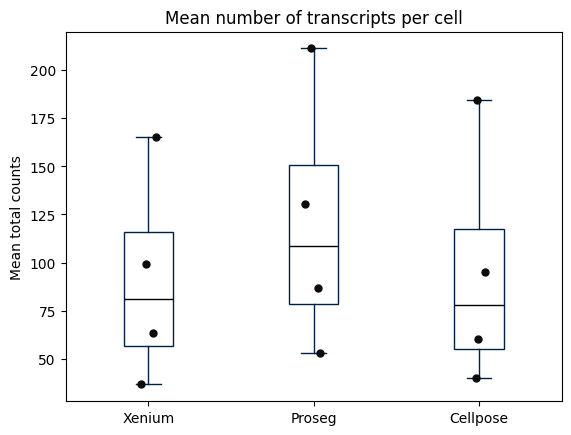

In [83]:
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Xenium':   [np.mean(x['total_counts']) for x in xen_results],
    'Proseg':   [np.mean(x['total_counts']) for x in proseg_results],  # presumably different
    'Cellpose': [np.mean(x['total_counts']) for x in cellpose_results],    # presumably different
}

colors = ["#002147", "#002147", "#002147"]
linewidth = 1

bp = plt.boxplot(data.values(), tick_labels=data.keys(), showfliers = False, patch_artist = True)


#colour each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor('None')
    patch.set_edgecolor(color)
    patch.set_alpha(1)
    patch.set_linewidth(linewidth)

# Also colour the whiskers and caps to match
for i, color in enumerate(colors):
    bp['whiskers'][i*2].set_color(color)
    bp['whiskers'][i*2+1].set_color(color)
    bp['whiskers'][i*2].set_linewidth(linewidth)
    bp['whiskers'][i*2+1].set_linewidth(linewidth)
    bp['caps'][i*2].set_color(color)
    bp['caps'][i*2+1].set_color(color)
    bp['caps'][i*2].set_linewidth(linewidth)
    bp['caps'][i*2+1].set_linewidth(linewidth)

#colour mean lines in boxes
for median in bp['medians']:
    median.set_color('black')

# Overlay individual points with jitter to avoid overlap
for i, (label, values) in enumerate(data.items(), start=1):
    jitter = np.random.uniform(-0.05, 0.05, size=len(values))
    plt.plot(np.full(len(values), i) + jitter, values, 'o',
             alpha=1, markersize=5, color="#0D0C0C")

plt.ylabel('Mean total counts')
plt.title('Mean number of transcripts per cell')
plt.show()

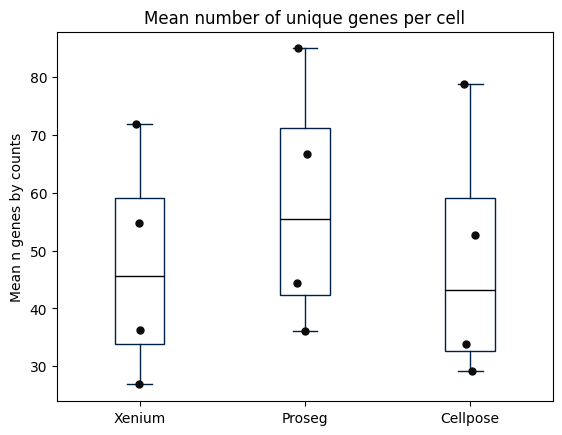

In [85]:
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Xenium':   [np.mean(x['n_genes_by_counts']) for x in xen_results],
    'Proseg':   [np.mean(x['n_genes_by_counts']) for x in proseg_results],  # presumably different
    'Cellpose': [np.mean(x['n_genes_by_counts']) for x in cellpose_results],    # presumably different
}

colors = ["#002147", "#002147", "#002147"]
linewidth = 1

bp = plt.boxplot(data.values(), tick_labels=data.keys(), showfliers = False, patch_artist = True)


#colour each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor('None')
    patch.set_edgecolor(color)
    patch.set_alpha(1)
    patch.set_linewidth(linewidth)

# Also colour the whiskers and caps to match
for i, color in enumerate(colors):
    bp['whiskers'][i*2].set_color(color)
    bp['whiskers'][i*2+1].set_color(color)
    bp['whiskers'][i*2].set_linewidth(linewidth)
    bp['whiskers'][i*2+1].set_linewidth(linewidth)
    bp['caps'][i*2].set_color(color)
    bp['caps'][i*2+1].set_color(color)
    bp['caps'][i*2].set_linewidth(linewidth)
    bp['caps'][i*2+1].set_linewidth(linewidth)

#colour mean lines in boxes
for median in bp['medians']:
    median.set_color('black')

# Overlay individual points with jitter to avoid overlap
for i, (label, values) in enumerate(data.items(), start=1):
    jitter = np.random.uniform(-0.05, 0.05, size=len(values))
    plt.plot(np.full(len(values), i) + jitter, values, 'o',
             alpha=1, markersize=5, color="#0D0C0C")

plt.ylabel('Mean n genes by counts')
plt.title('Mean number of unique genes per cell')
plt.show()

In [95]:
sum([len(x) for x in xen_results])

304116

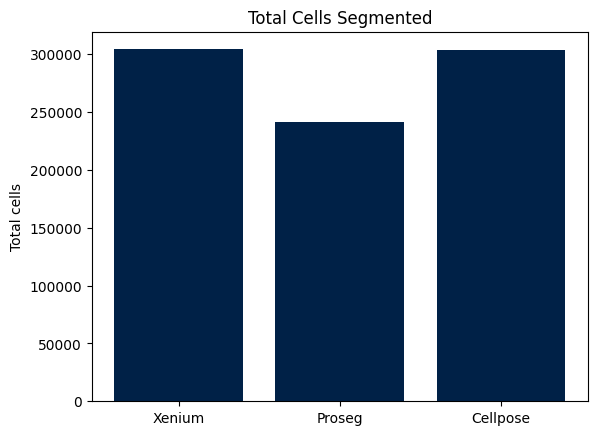

In [99]:
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Xenium':   sum([len(x) for x in xen_results]),
    'Proseg':   sum([len(x) for x in proseg_results]),
    'Cellpose': sum([len(x) for x in cellpose_results]),
}

colors = ["#002147", "#002147", "#002147"]

plt.bar(data.keys(), data.values(), color=colors)

plt.ylabel('Total cells')
plt.title('Total Cells Segmented')
plt.show()